# SAMap Cross-Species Analysis

Template notebook using `labcore.integration` and `labcore.scrnaseq`.
Edit the **Configuration** cell, then run all.

**Kernel:** `samap` (see `environment_samap.yml`)

## 1 · Configuration

In [1]:
import os

# ---------------------------------------------------------------------------
# Species
# ---------------------------------------------------------------------------
# Add or remove entries to change the number of species in the analysis.
# Keys are the short IDs SAMap uses internally (must match the BLAST map filenames).

species_files = {
    "ml": "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/objs/Progenitor_Subset_2_integrated_merged.h5ad",
    "sc": "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/data/ref_atlas/S_mansoni/S_mansoni_Progeny_cells_pr.h5ad",
}

# Column in .obs that holds cluster / cell-type labels for each species
cluster_keys = {
    "ml": "final_label_SAMap",
    "sc": "cell_type",
}

# Human-readable names for plot legends
species_display = {
    "ml": "M. lignano",
    "sc": "S. mansoni",
}

# Colors for each species
species_colors = {
    "ml": "#377EB8",
    "sc": "#008000",
}

# Left-to-right order for Sankey diagrams
sankey_order = ["ml", "sc"]

# ---------------------------------------------------------------------------
# SAMap
# ---------------------------------------------------------------------------

samap_cell_type = "Progenitor_cluster"

maps_dir      = "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/data/ref_atlas/maps/"          # directory with BLAST / homology maps
samap_obj     = os.path.join("/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/objs/", samap_cell_type, "/", "SAMap_cross_species_annotation.obj")      # where to save / load the SAMap object
run_samap     = True                       # False = load pre-computed object

# ---------------------------------------------------------------------------
# GenePairFinder
# ---------------------------------------------------------------------------
run_genepairfinder     = True                       # False = load pre-computed object

# ---------------------------------------------------------------------------
# Gene-pair expression overlaps
# ---------------------------------------------------------------------------
# TSV with one row per gene pair. Required columns: one per species key
# (e.g. "ml", "sm", "sc") containing gene IDs. Leave a cell blank / NaN
# to exclude that species from a specific pair.
# Optional columns:
#   output_prefix  — filename prefix (defaults to gene IDs joined by "_")
#   label          — human-readable description (used only as a comment)
#
# Example row:
#   label    ml                sm                    sc          output_prefix
#   macpiwi  Mlig455-019997    dd-Smed-v4-15930-0-1              overlap_macpiwi
#
gene_pairs_file = "None"  # set None to skip this section

# ---------------------------------------------------------------------------
# Output directories
# ---------------------------------------------------------------------------
out_dir     = "/data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/"
figures_dir = os.path.join(out_dir, "figures/", samap_cell_type)
tables_dir  = os.path.join(out_dir, "tables/", samap_cell_type)
objs_dir    = os.path.join(out_dir, "objs/", samap_cell_type)

for d in [figures_dir, tables_dir, objs_dir]:
    os.makedirs(d, exist_ok=True)

# ---------------------------------------------------------------------------
# Analysis options
# ---------------------------------------------------------------------------
describe_data     = True   # print a structural summary of each h5ad
run_umap_sweep    = False   # sweep over UMAP min_dist values (exploratory)
align_thr         = 0.1    # mapping-score threshold (Sankey, CellTypeTriangles)
n_top             = 0      # n_top for get_mapping_scores (0 = keep all)
embedding_key     = "X_umap_samap"

## 2 · Imports

In [2]:
import dill
import warnings
import numpy as np
import pandas as pd
import scanpy as sc

from samap import SAMAP
from samap.analysis import (
    get_mapping_scores,
    GenePairFinder,
    CellTypeTriangles,
)

from samap_extension import plotting as splt
from samap_extension import utils

## 3 · (Optional) Inspect input data

In [3]:
if describe_data:
    for sp, path in species_files.items():
        print(f"\n{'='*60}")
        print(f"Species: {species_display.get(sp, sp)}  ({sp})")
        print(f"{'='*60}")
        adata = sc.read_h5ad(path)
        utils.describe_adata(adata)
        del adata


Species: M. lignano  (ml)
Shape: 20,093 cells × 59,995 genes

Cell metadata (obs):
  20,093 cells × 55 columns

  --- orig.ident ---
    11_unsorted_3dph_TCGGGCAAGCTACTGT:  11_unsorted_3dph
    11_unsorted_3dph_CCTTGTGAGCGACCCT:  11_unsorted_3dph
    11_unsorted_3dph_TCACGCTTCAACTGAC:  11_unsorted_3dph
    11_unsorted_3dph_GAGTGTTAGCTGAGTG:  11_unsorted_3dph
    11_unsorted_3dph_TCATGCCAGAAGTCAT:  11_unsorted_3dph
    11_unsorted_3dph_ATGGAGGTCGCAGTTA:  11_unsorted_3dph
    11_unsorted_3dph_CGGAACCGTCGCGTCA:  11_unsorted_3dph
    11_unsorted_3dph_TTCCGTGGTCTGTAAC:  11_unsorted_3dph
    11_unsorted_3dph_TGTGAGTCAGGCCTGT:  11_unsorted_3dph
    11_unsorted_3dph_AACGTCACAGCTGAGA:  11_unsorted_3dph

  --- nCount_RNA ---
    11_unsorted_3dph_TCGGGCAAGCTACTGT:  3452.0
    11_unsorted_3dph_CCTTGTGAGCGACCCT:  3479.0
    11_unsorted_3dph_TCACGCTTCAACTGAC:  3482.0
    11_unsorted_3dph_GAGTGTTAGCTGAGTG:  3471.0
    11_unsorted_3dph_TCATGCCAGAAGTCAT:  3472.0
    11_unsorted_3dph_ATGGAGGTCGCAGTTA: 

## 4 · Run or load SAMap

In [4]:
samap_obj_path = os.path.join(objs_dir, "SAMap_cross_species_annotation.obj")

if run_samap:
    sm = SAMAP(species_files, f_maps=maps_dir)
    sm.run()
    with open(samap_obj_path, "wb") as fh:
        dill.dump(sm, fh)
    print(f"SAMap object saved to: {samap_obj_path}")
else:
    with open(samap_obj_path, "rb") as fh:
        sm = dill.load(fh)
    print(f"SAMap object loaded from: {samap_obj_path}")

INFO: Using backend: cpu
INFO: Processing data ml from: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/objs/Progenitor_Subset_2_integrated_merged.h5ad
INFO: Running SAM algorithm
INFO: Iteration: 0, Convergence: 1.000000
INFO: Iteration: 1, Convergence: 0.885693
INFO: Iteration: 2, Convergence: 0.038272
INFO: Elapsed time: 66.05 seconds
INFO: Not updating the manifold...
INFO: Processing data sc from: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/data/ref_atlas/S_mansoni/S_mansoni_Progeny_cells_pr.h5ad
INFO: Running SAM algorithm
INFO: Iteration: 0, Convergence: 1.000000
INFO: Iteration: 1, Convergence: 0.736601
INFO: Iteration: 2, Convergence: 0.014742
INFO: Elapsed time: 33.64 seconds
INFO: Not updating the manifold...
INFO: 27776 'ml' gene symbols match between the datasets and the BLAST graph.
INFO: 7249 'sc' gene symbols match between the datasets and the BLAST graph.
INFO: Prepping datasets for translation.
INFO: Translating feature spaces pairwise.
INFO: Project

SAMap object saved to: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/objs/Progenitor_cluster/SAMap_cross_species_annotation.obj


## 5 · Mapping scores

In [5]:
D, MappingTable = get_mapping_scores(sm, cluster_keys, n_top=n_top)

# Save mapping table
table_path = os.path.join(tables_dir, "mapping_scores.tsv")
pd.DataFrame(MappingTable).to_csv(table_path, sep="\t")
print(f"Mapping table saved to: {table_path}")

Mapping table saved to: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/tables/Progenitor_cluster/mapping_scores.tsv


## 6 · Joint UMAP — coloured by species

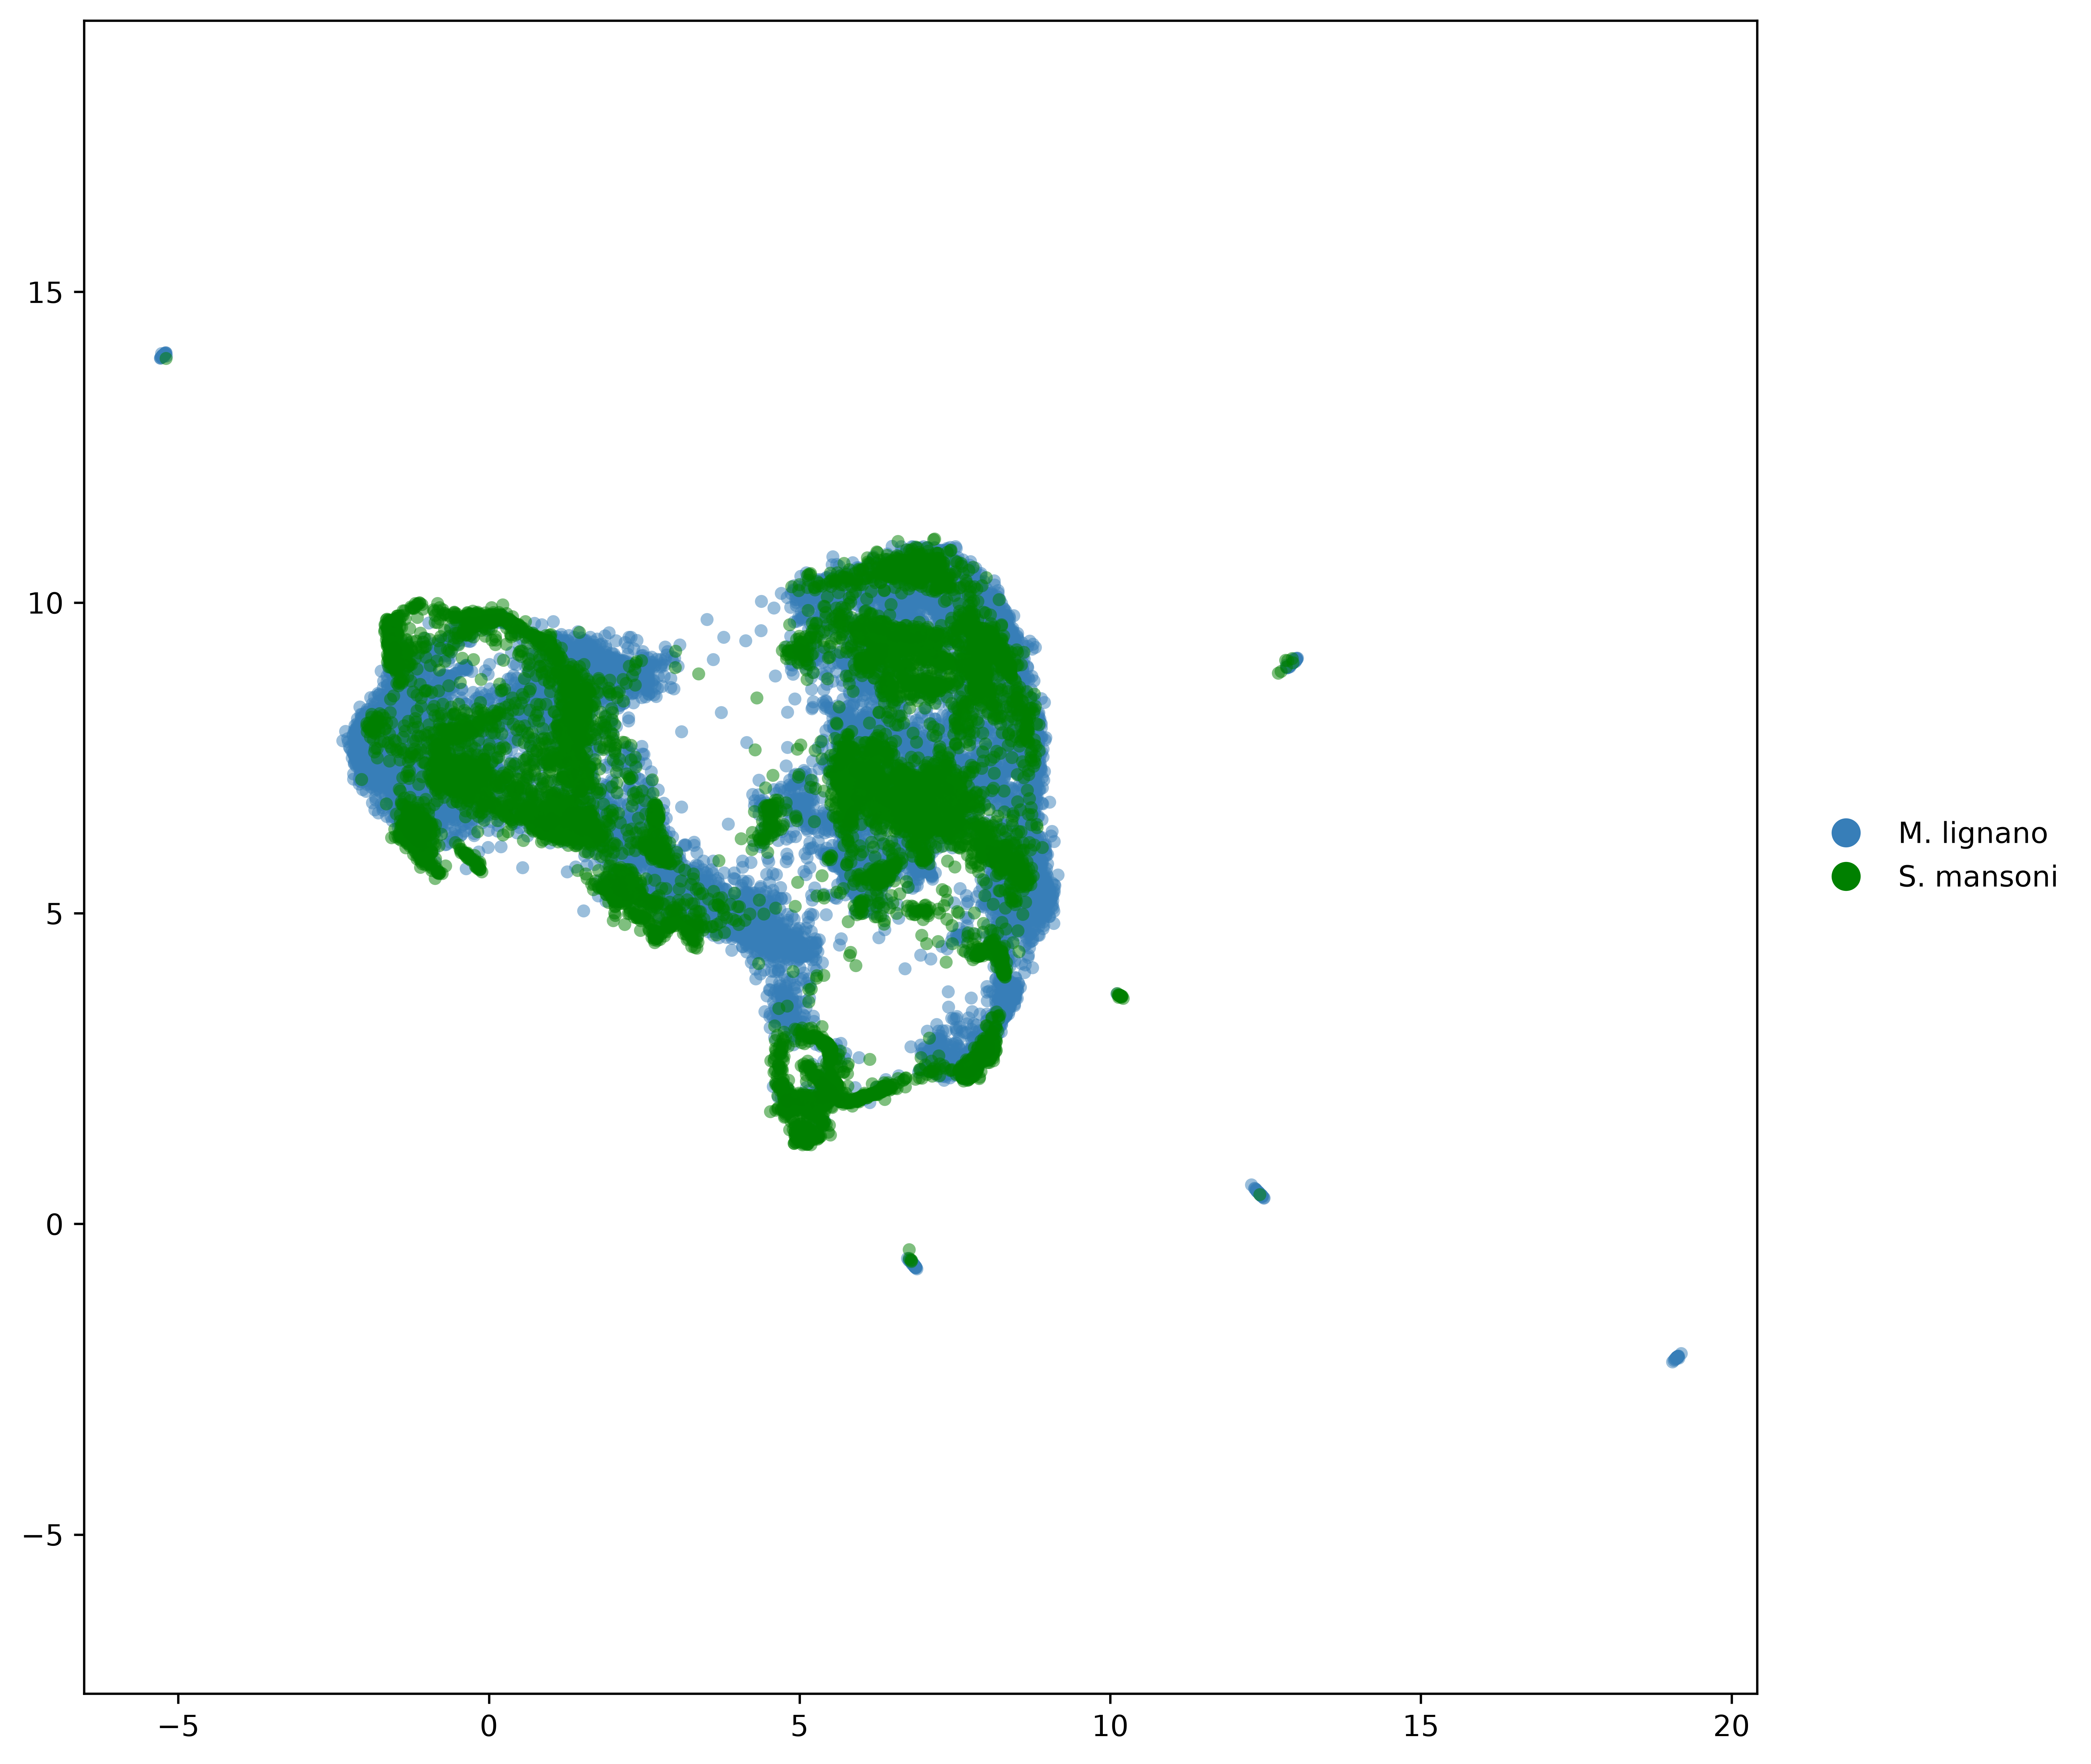

In [6]:
fig, ax = splt.square_scatter(
    sm,
    COLORS=species_colors,
    species_labels=species_display,
    figsize=(8, 8),
    dpi=600,
    s=20,
    alpha=0.5,
)
fig.savefig(
    os.path.join(figures_dir, "umap_by_species.pdf"),
    dpi=600,
    bbox_inches="tight",
)

## 7 · Joint UMAP — coloured by cell type per species

Produces one figure per species, highlighting that species' cluster
labels against all other cells in gray.

Saved: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/figures/Progenitor_cluster/umap_labels_ml.pdf
Saved: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/figures/Progenitor_cluster/umap_labels_sc.pdf


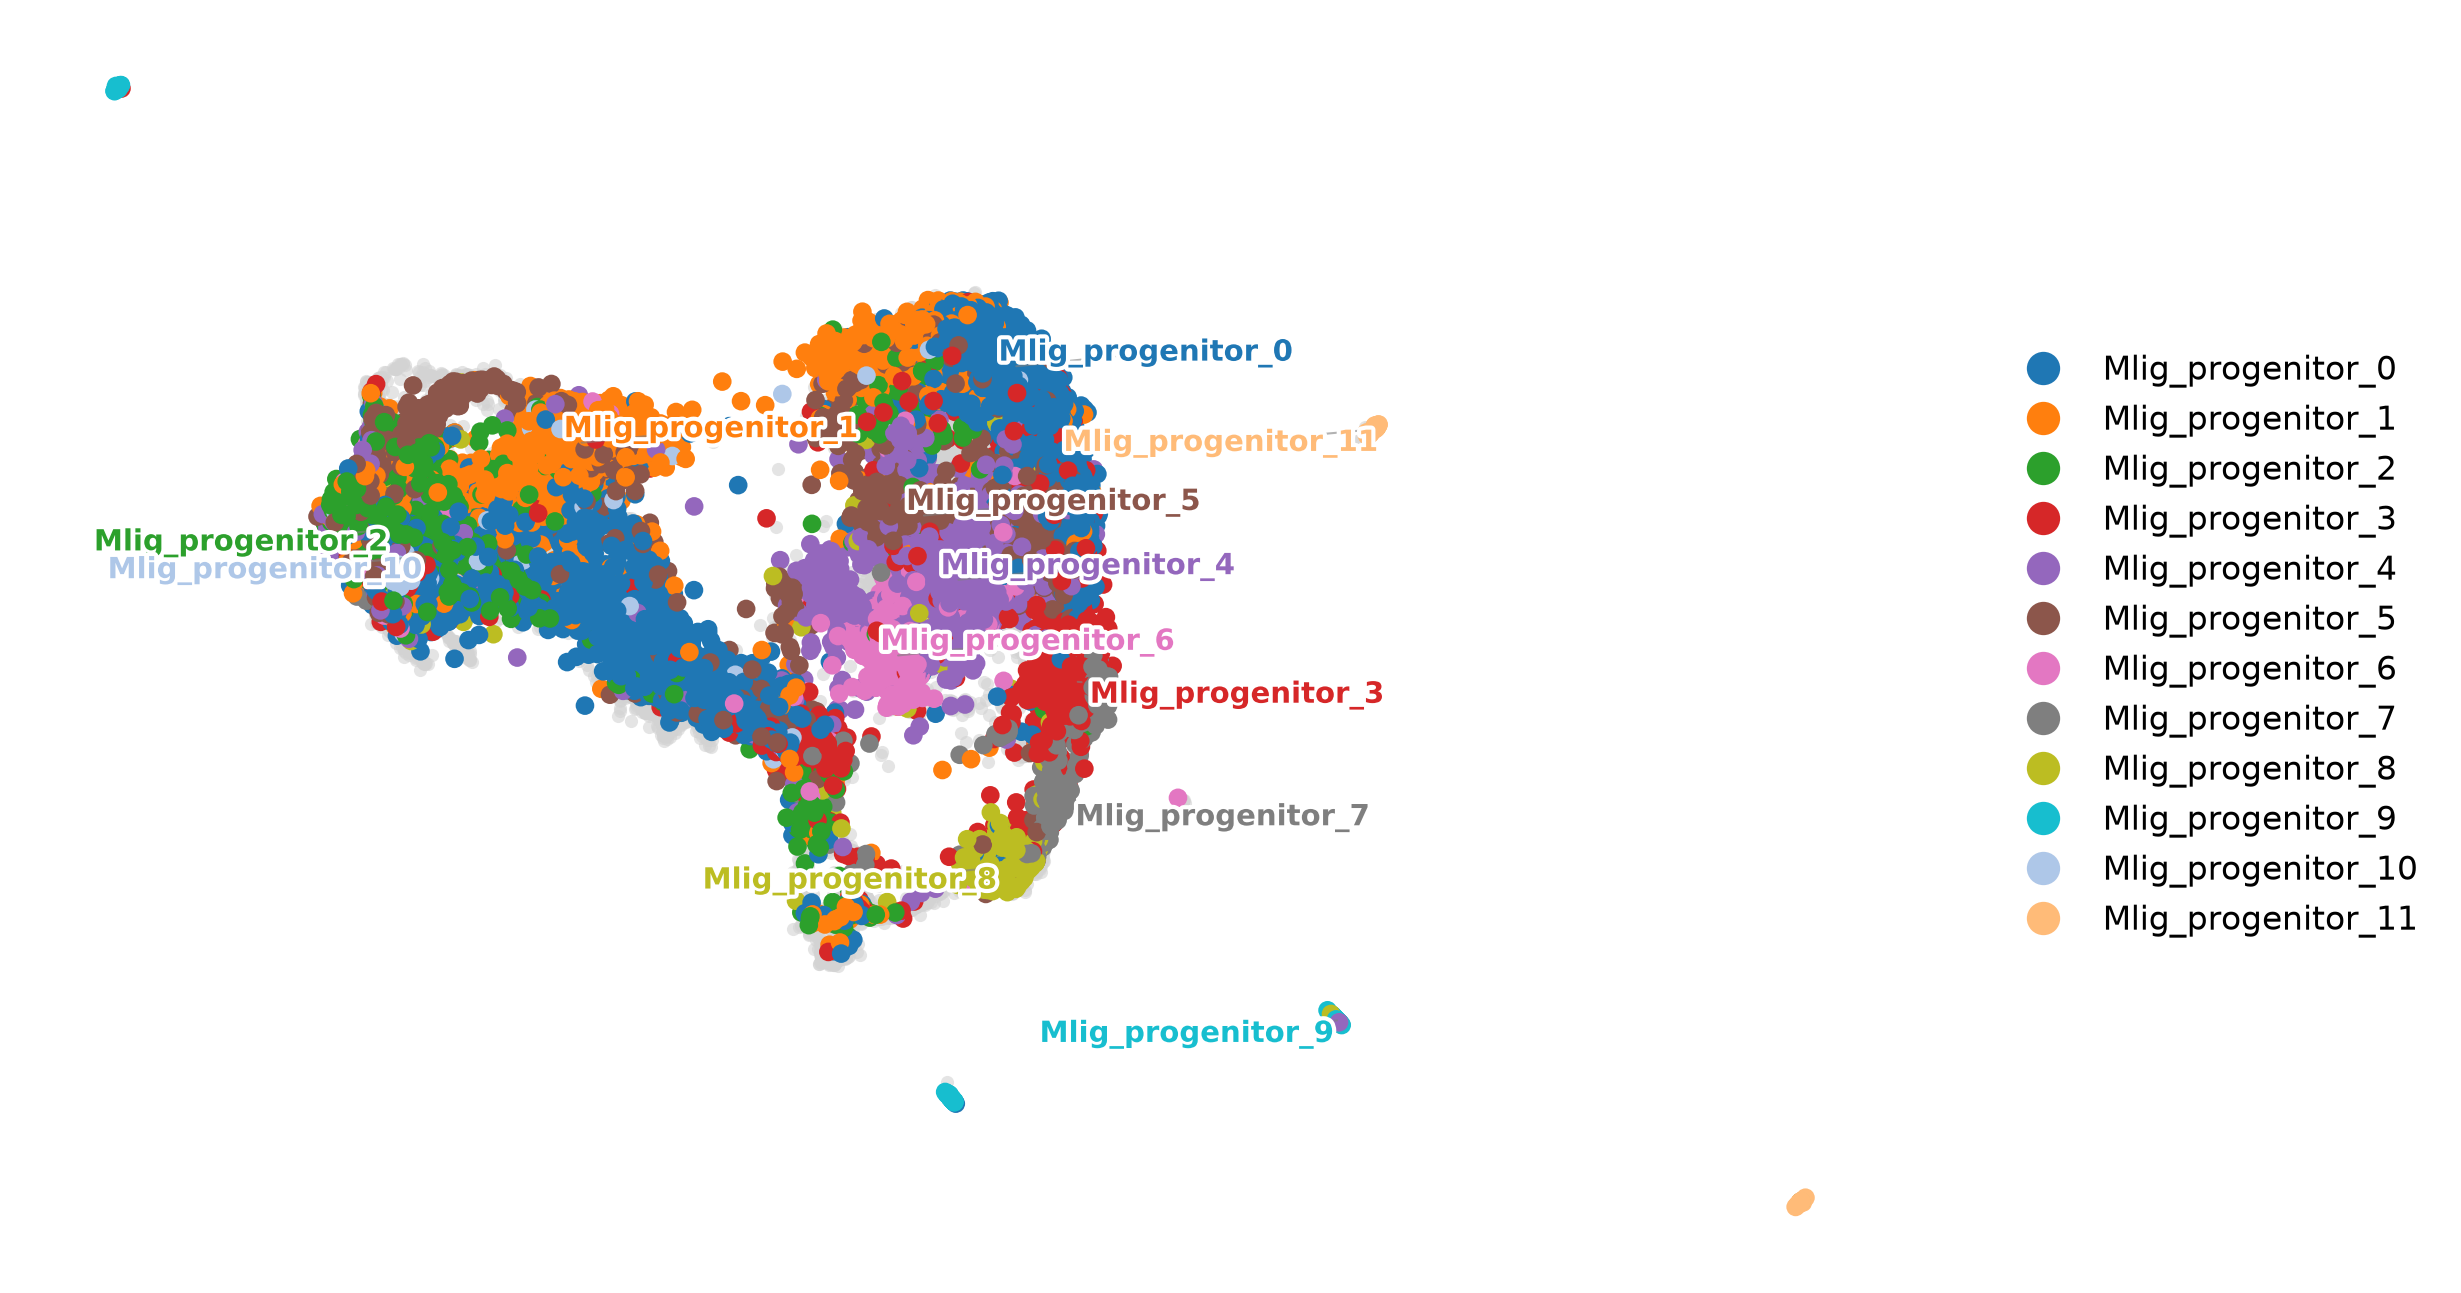

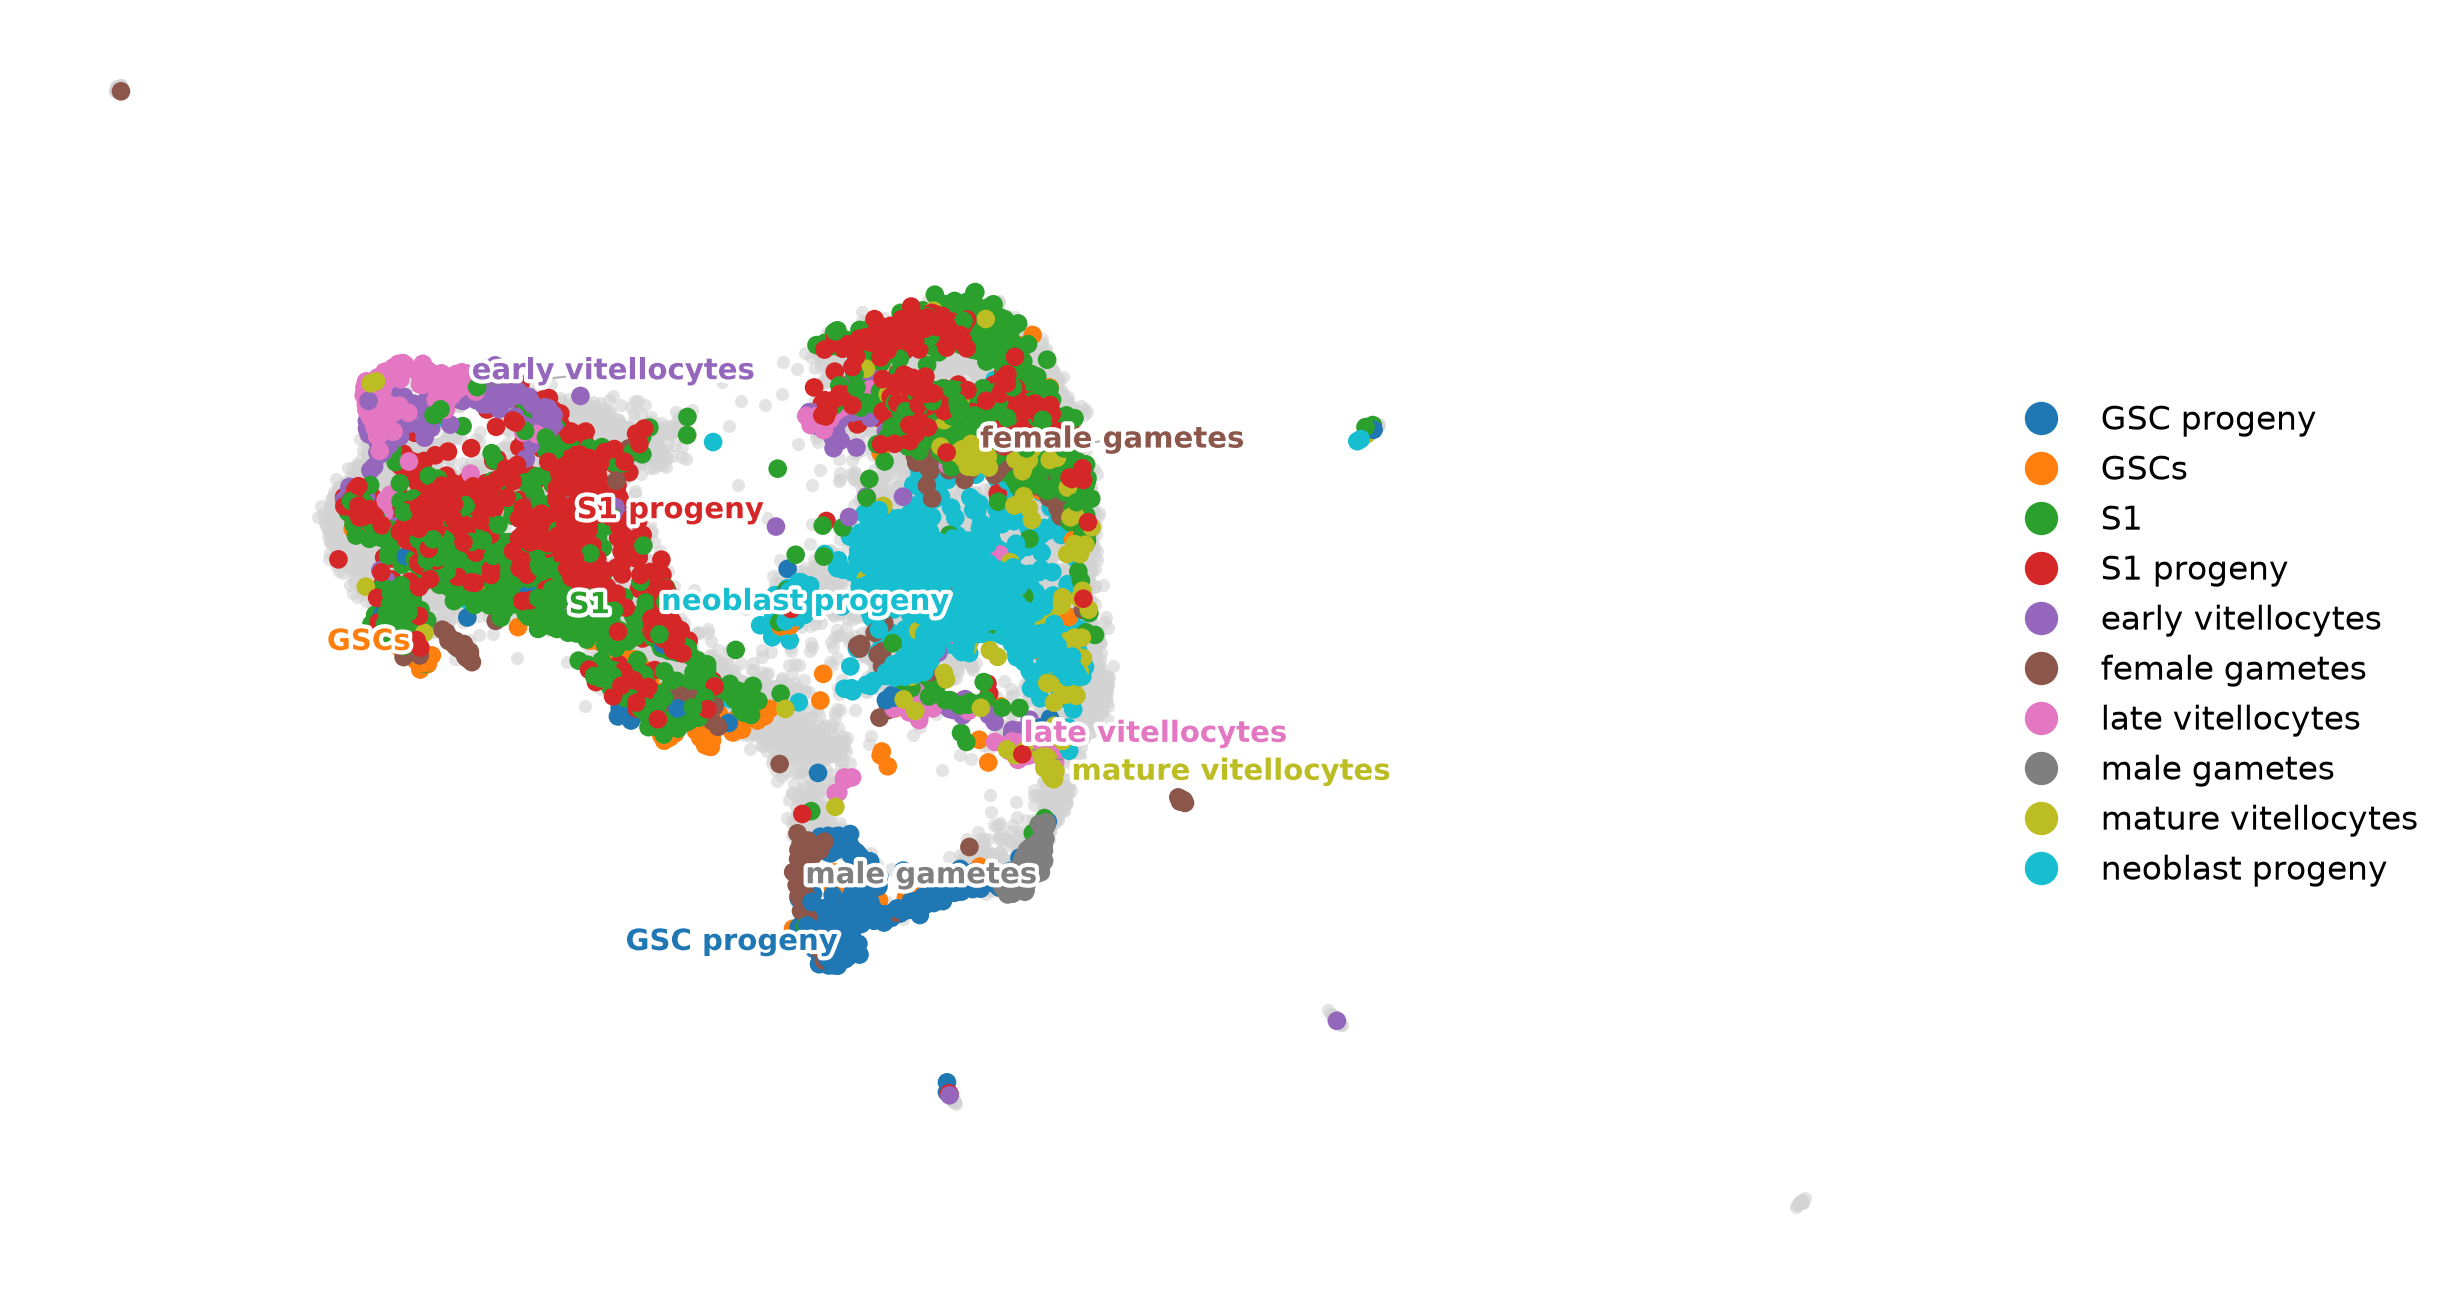

In [7]:
for sp, col in cluster_keys.items():
    out_path = os.path.join(figures_dir, f"umap_labels_{sp}.pdf")
    fig, ax = splt.plot_joint_umap(
        sm,
        species=sp,
        label_col=col,
        embedding_key=embedding_key,
        figsize=(8, 8),
        dpi=300,
        s_other=10,     # background cells
        s_target=20,    # target species cells
        save_to=out_path,
        label_clusters=True,
        label_fontsize=7,
        label_outline=True,
    )
    print(f"Saved: {out_path}")

## 8 · Sankey diagram

Uses `sankey_plot_3` for 3 species (two-panel layout keeping the
middle column aligned) and falls back to a single-panel Sankey for
2 species.

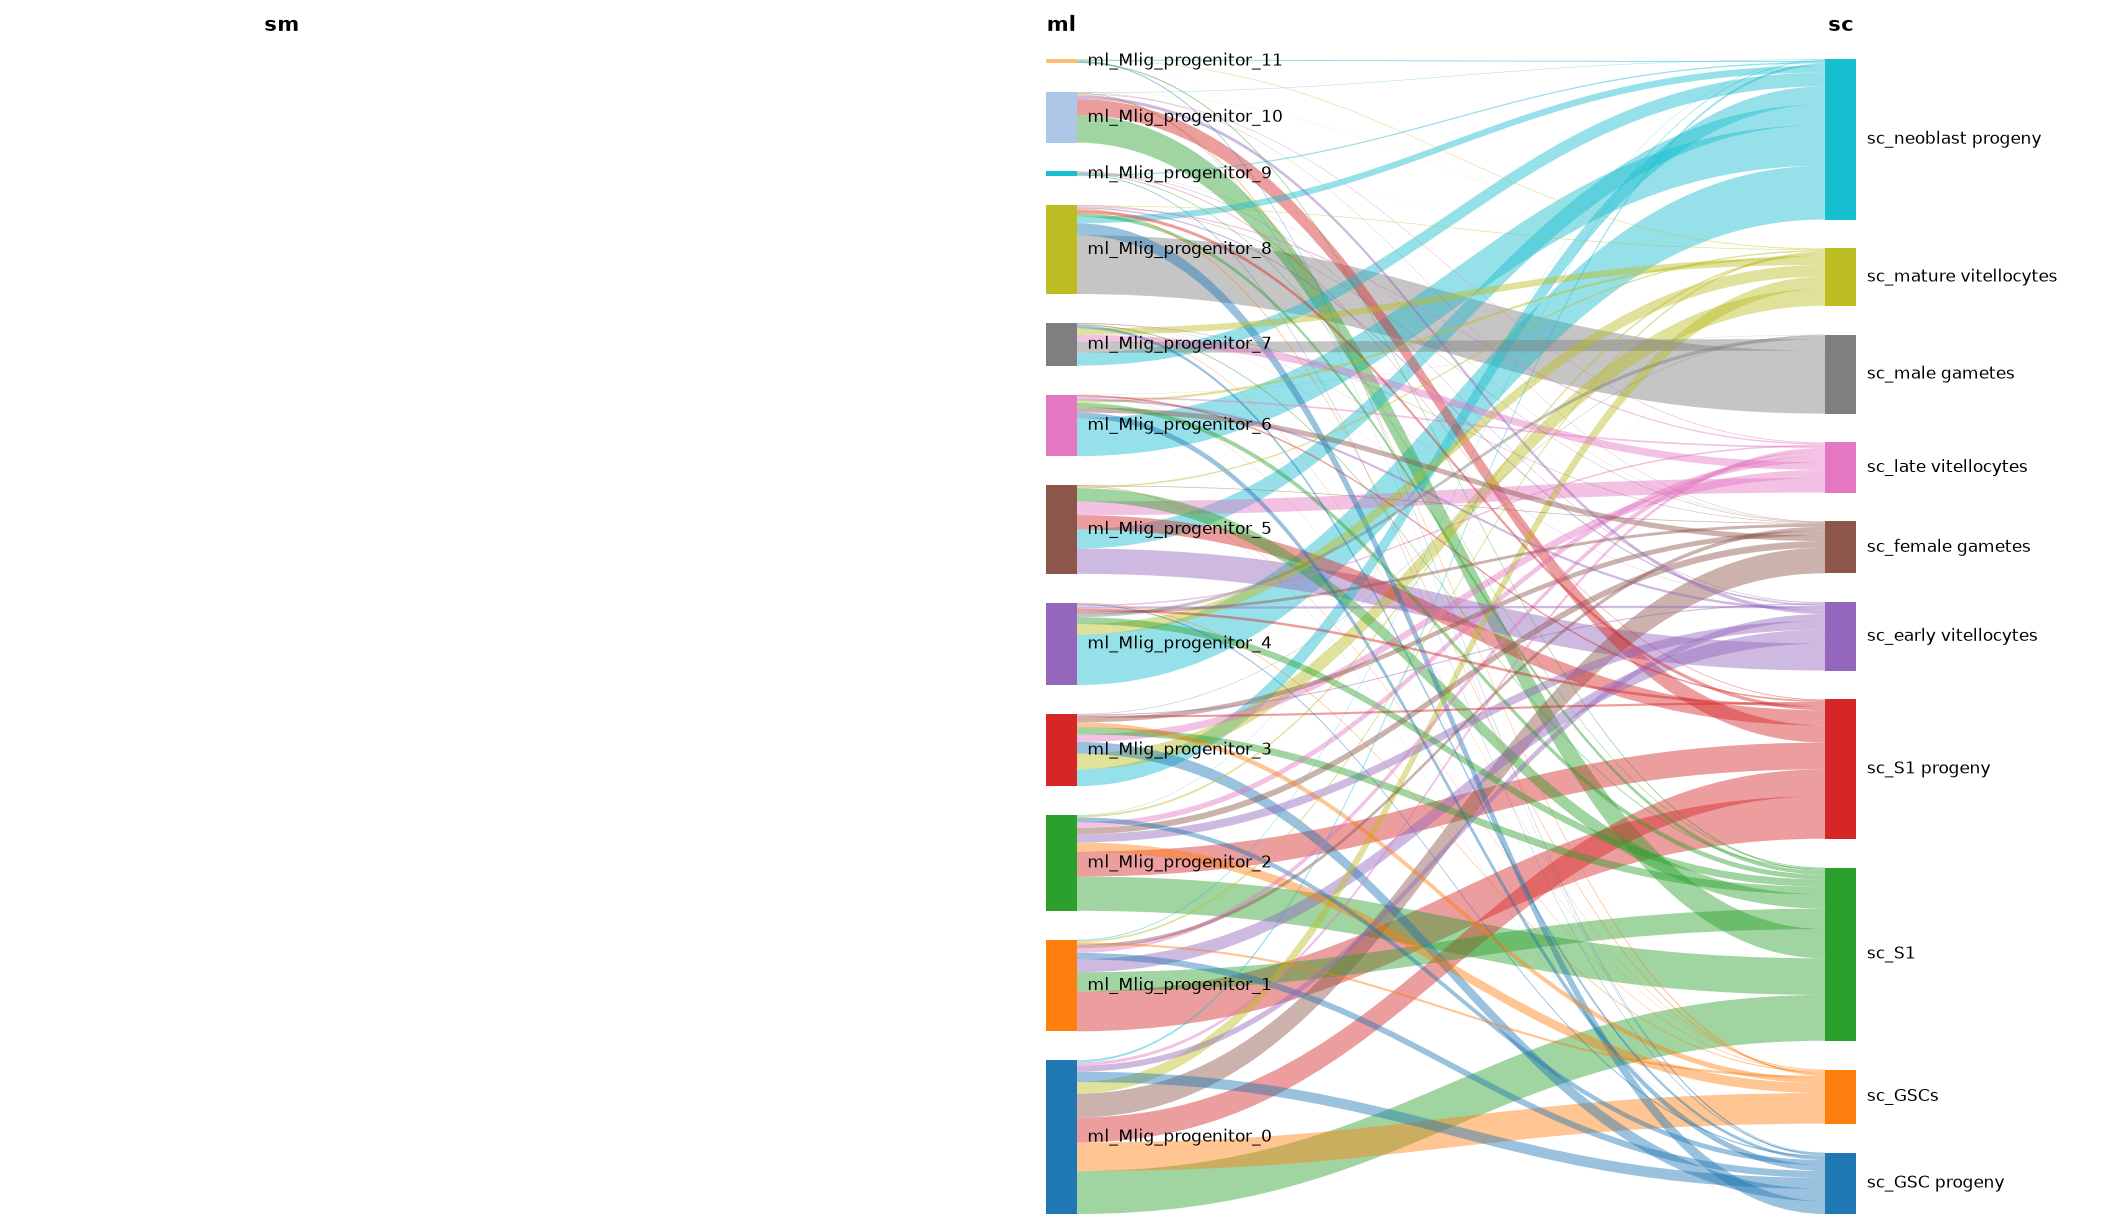

(<Figure size 2700x1500 with 1 Axes>, <Axes: >)

In [8]:
n_species = len(species_files)
two_panel = n_species == 2

sankey = splt.sankey_plot_3(
    MappingTable,
    species_order=["sm", "ml", "sc"],
    align_thr=0,
    figsize=(18, 10),
    save_to=os.path.join(figures_dir, "sankey_thr_0.pdf"),
)
sankey

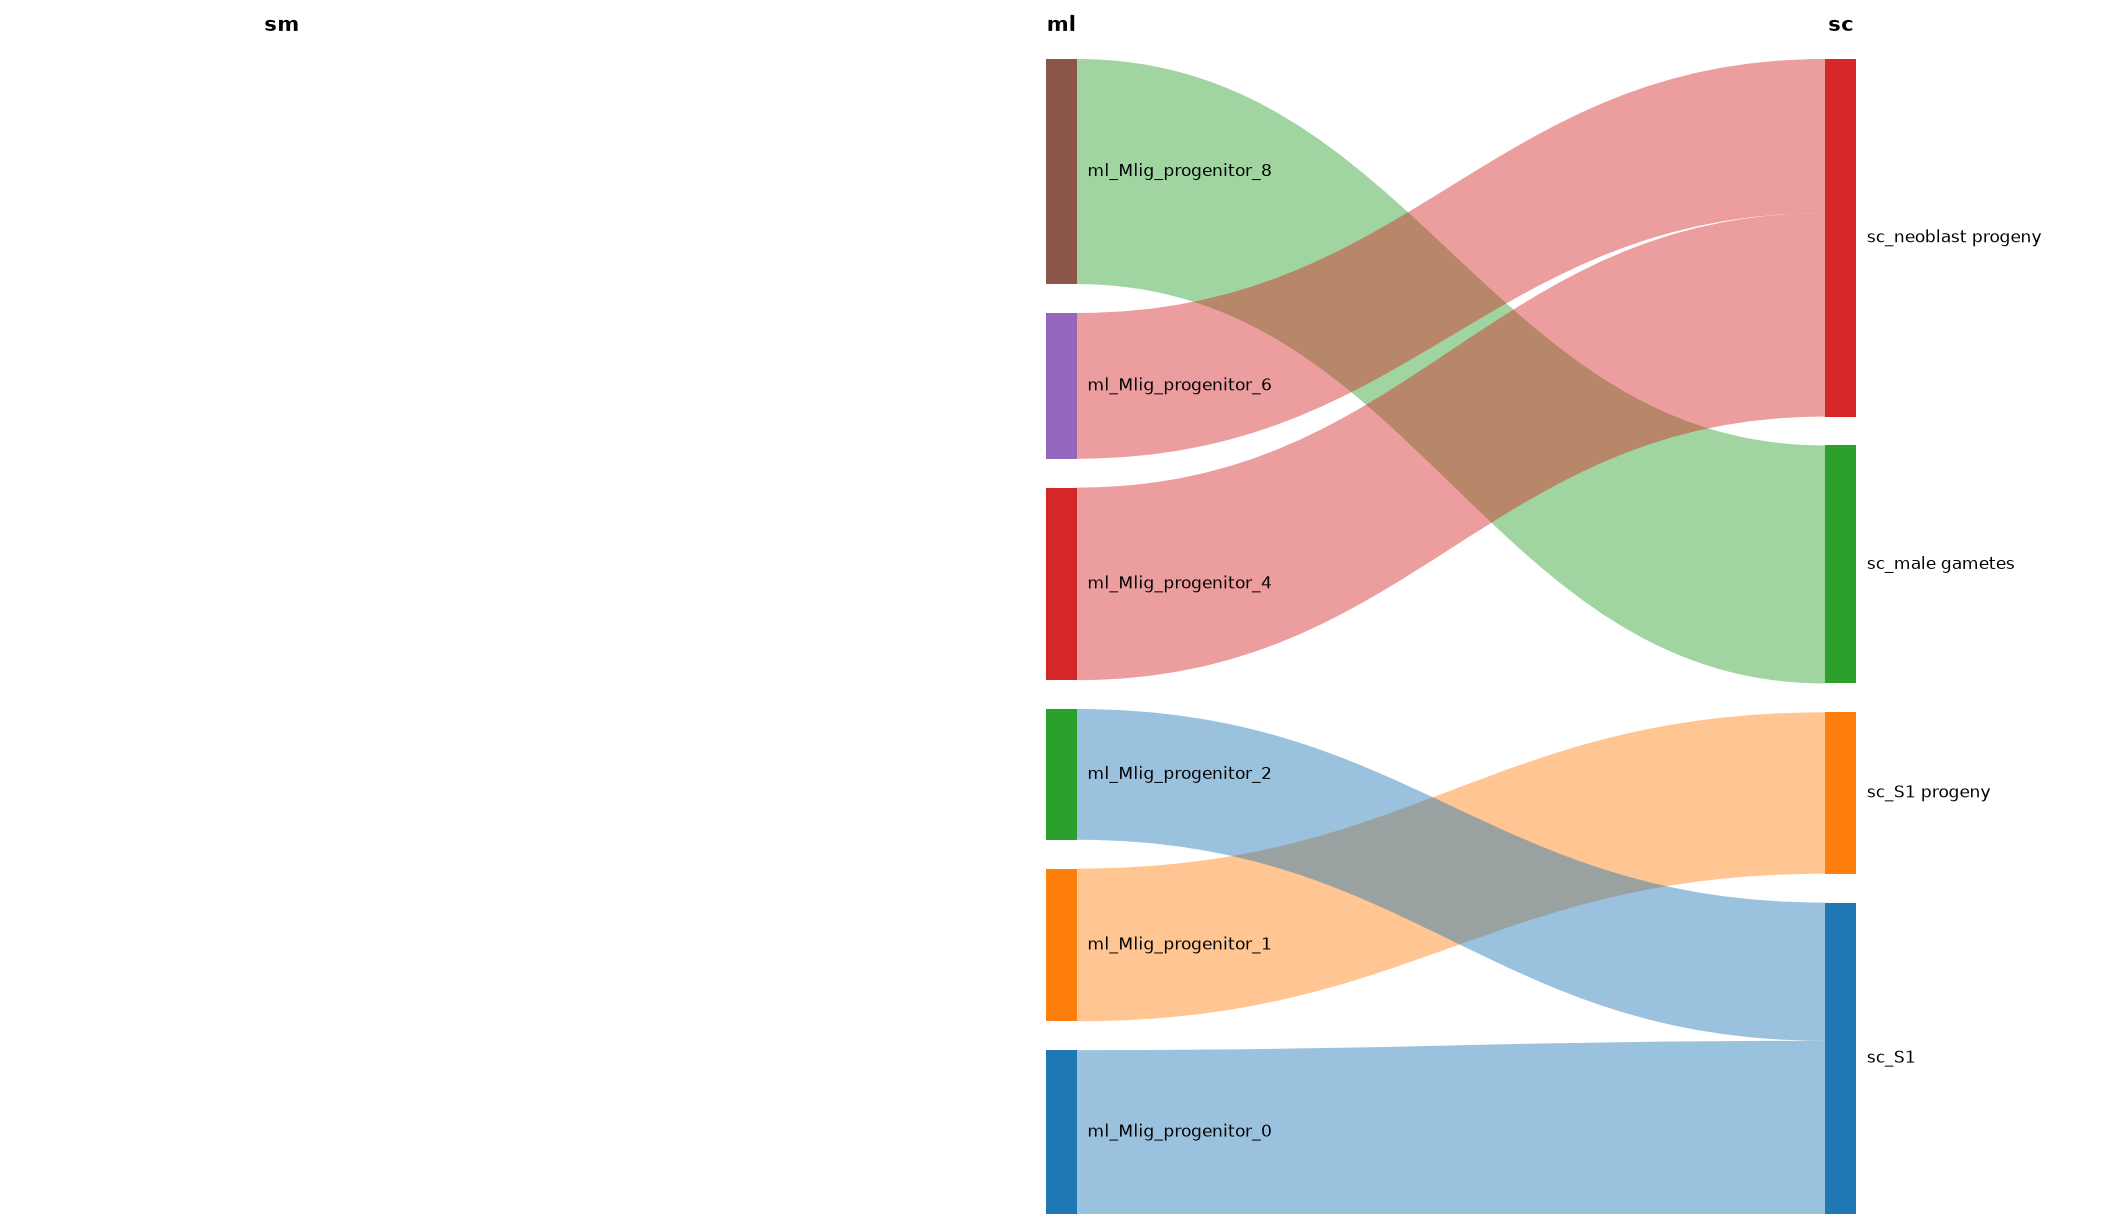

(<Figure size 2700x1500 with 1 Axes>, <Axes: >)

In [9]:
n_species = len(species_files)
two_panel = n_species == 2

sankey = splt.sankey_plot_3(
    MappingTable,
    species_order=["sm", "ml", "sc"],
    align_thr=0.3,
    figsize=(18, 10),
    save_to=os.path.join(figures_dir, "sankey_thr_0_3.pdf"),
)
sankey

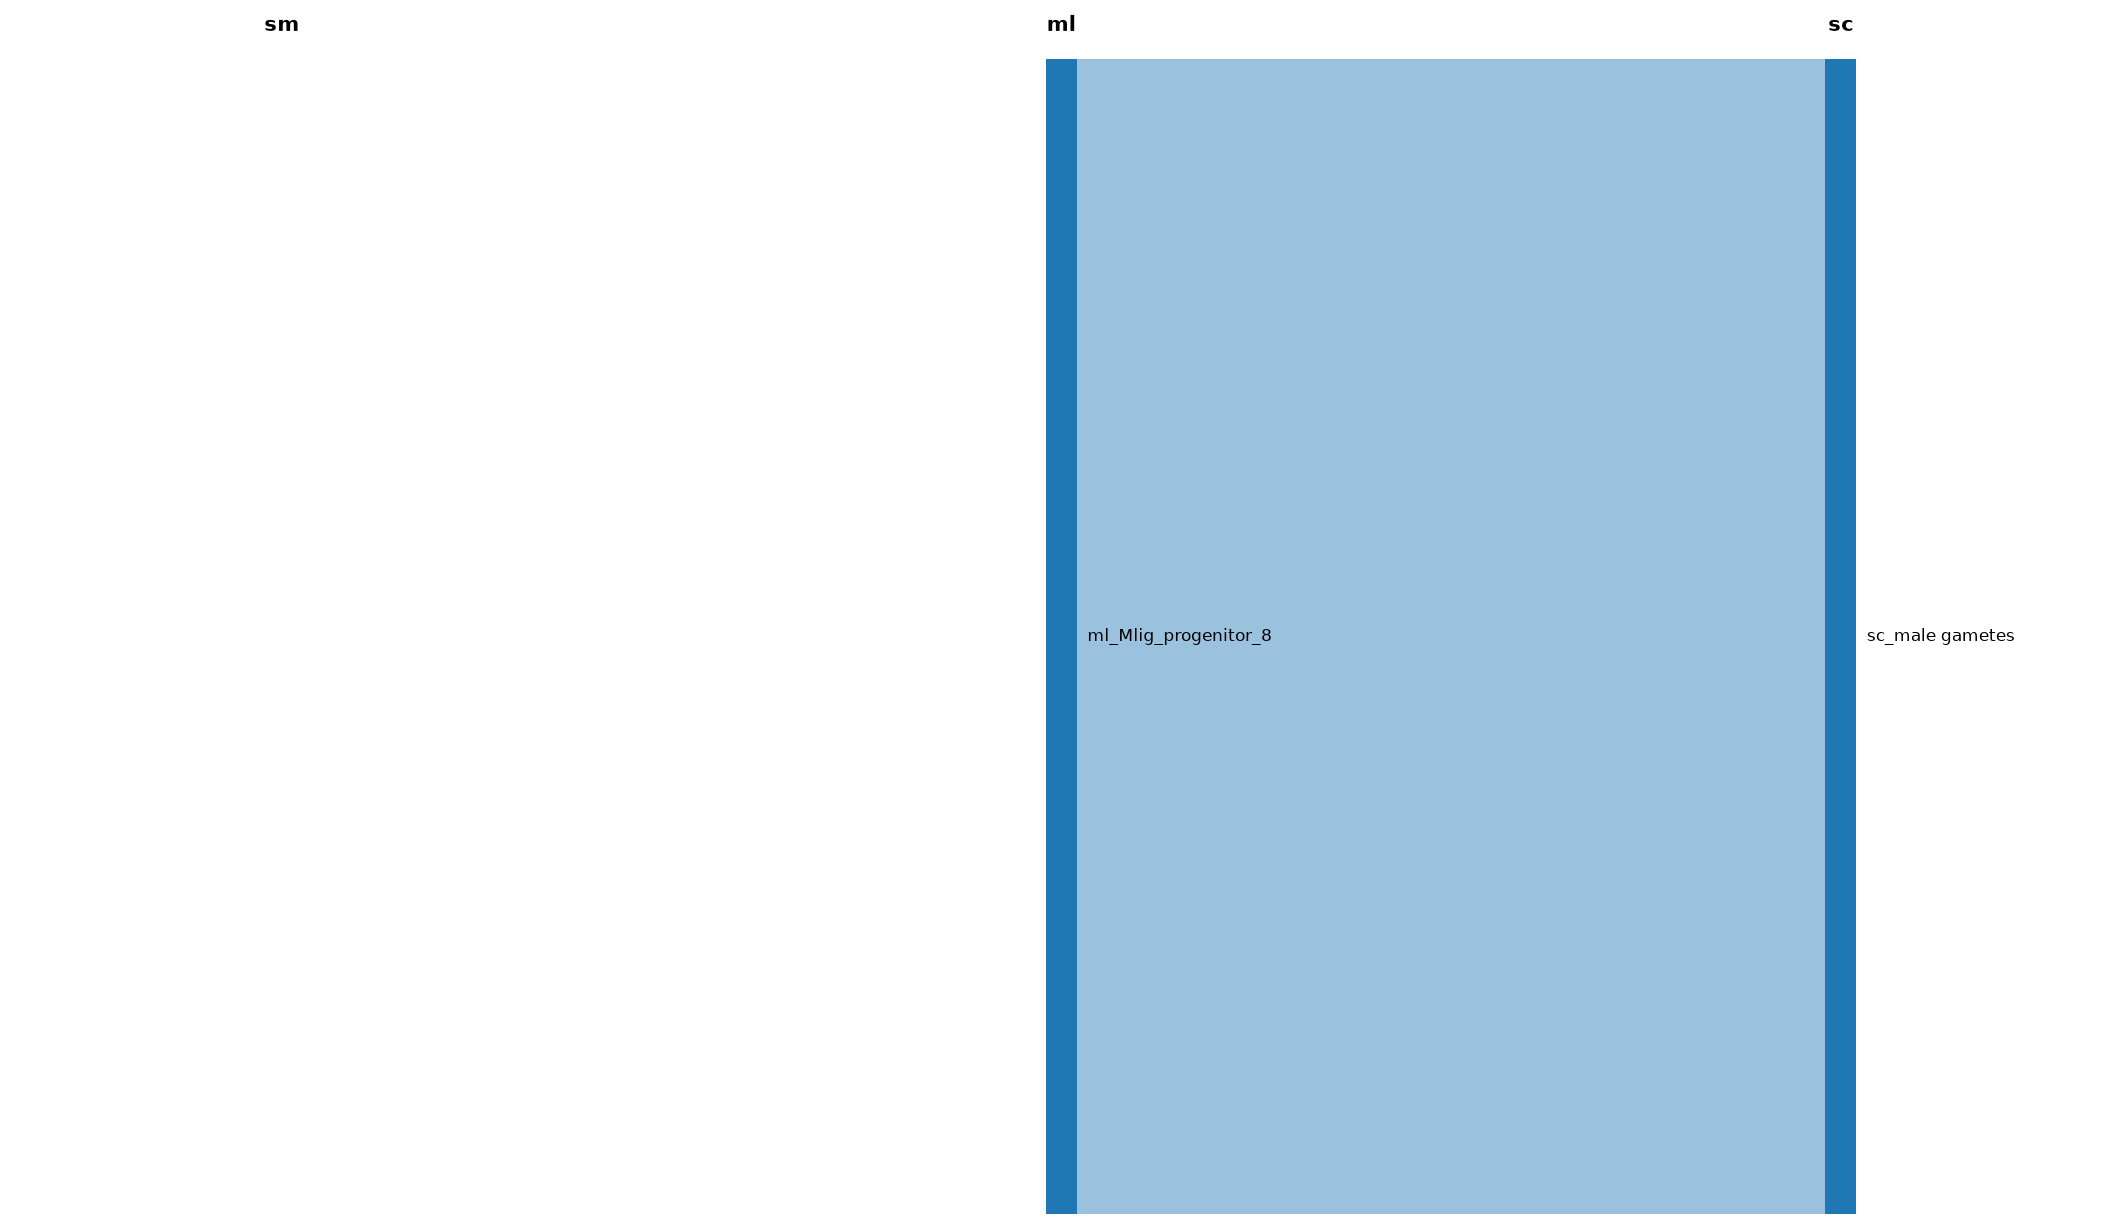

(<Figure size 2700x1500 with 1 Axes>, <Axes: >)

In [10]:
n_species = len(species_files)
two_panel = n_species == 2

sankey = splt.sankey_plot_3(
    MappingTable,
    species_order=["sm", "ml", "sc"],
    align_thr=0.5,
    figsize=(18, 10),
    save_to=os.path.join(figures_dir, "sankey_thr_0_5.pdf"),
)
sankey

## 10 · Gene pair finder

In [11]:
gpf = GenePairFinder(sm, keys=cluster_keys)
gene_pairs = gpf.find_all(align_thr=0)

gpf_path = os.path.join(objs_dir, "gene_pair_finder_thr_0.obj")
with open(gpf_path, "wb") as fh:
    dill.dump(gpf, fh)

pairs_path = os.path.join(tables_dir, "gene_pairs_thr_0.tsv")
gene_pairs.to_csv(pairs_path, sep="\t")
print(f"Gene pairs saved to: {pairs_path}")
gene_pairs.head(20)

INFO: Finding cluster-specific markers in ml:final_label_SAMap.
INFO: Finding cluster-specific markers in sc:cell_type.
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;GSC progeny
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;GSCs
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;S1
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;S1 progeny
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;early vitellocytes
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;female gametes
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;late vitellocytes
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;male gametes
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;mature vitellocytes
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;neoblast progeny
INFO: Calculating

Gene pairs saved to: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/tables/Progenitor_cluster/gene_pairs_thr_0.tsv


,ml_Mlig_progenitor_0;sc_GSC progeny,ml_Mlig_progenitor_0;sc_GSC progeny_pval1,ml_Mlig_progenitor_0;sc_GSC progeny_pval2,ml_Mlig_progenitor_0;sc_GSCs,ml_Mlig_progenitor_0;sc_GSCs_pval1,ml_Mlig_progenitor_0;sc_GSCs_pval2,ml_Mlig_progenitor_0;sc_S1,ml_Mlig_progenitor_0;sc_S1_pval1,ml_Mlig_progenitor_0;sc_S1_pval2,ml_Mlig_progenitor_0;sc_S1 progeny,...,ml_Mlig_progenitor_9;sc_female gametes_pval2,ml_Mlig_progenitor_9;sc_late vitellocytes,ml_Mlig_progenitor_9;sc_late vitellocytes_pval1,ml_Mlig_progenitor_9;sc_late vitellocytes_pval2,ml_Mlig_progenitor_9;sc_mature vitellocytes,ml_Mlig_progenitor_9;sc_mature vitellocytes_pval1,ml_Mlig_progenitor_9;sc_mature vitellocytes_pval2,ml_Mlig_progenitor_9;sc_neoblast progeny,ml_Mlig_progenitor_9;sc_neoblast progeny_pval1,ml_Mlig_progenitor_9;sc_neoblast progeny_pval2
0,ml_Mlig455-034764;sc_Smp-035270,0.000591,0.0,ml_Mlig455-011850;sc_Smp-162370,0.0,0.0,ml_Mlig455-013128;sc_Smp-162370,0.0,0.0,ml_Mlig455-013128;sc_Smp-162370,...,0.000068,ml_Mlig455-027840;sc_Smp-003610,0.0,0.0,ml_Mlig455-018012;sc_Smp-194770,0.004536,0.000029,ml_Mlig455-060009;sc_Smp-083240,0.000032,0.0
1,ml_Mlig455-017241;sc_Smp-090120,0.0,0.0,ml_Mlig455-013128;sc_Smp-162370,0.0,0.0,ml_Mlig455-011850;sc_Smp-162370,0.0,0.0,ml_Mlig455-033217;sc_Smp-086470,...,0.000011,ml_Mlig455-020959;sc_Smp-000660,0.005746,0.0,ml_Mlig455-018031;sc_Smp-194770,0.009753,0.000029,ml_Mlig455-000055;sc_Smp-340490,0.0,0.0
2,ml_Mlig455-017241;sc_Smp-030730,0.0,0.0,ml_Mlig455-023934;sc_Smp-100090,0.0,0.0,ml_Mlig455-061085;sc_Smp-086860,0.0,0.0,ml_Mlig455-011850;sc_Smp-162370,...,0.008307,ml_Mlig455-002504;sc_Smp-172110,0.0,0.0,ml_Mlig455-048385;sc_Smp-004910,0.006465,0.000148,ml_Mlig455-027840;sc_Smp-083240,0.0,0.0
3,ml_Mlig455-024505;sc_Smp-340630,0.0,0.0,ml_Mlig455-061085;sc_Smp-086860,0.0,0.0,ml_Mlig455-035433;sc_Smp-086860,0.0,0.0,ml_Mlig455-010835;sc_Smp-086470,...,0.006455,ml_Mlig455-002664;sc_Smp-172110,0.0,0.0,ml_Mlig455-001619;sc_Smp-210500,0.000045,0.0,ml_Mlig455-002664;sc_Smp-172110,0.0,0.0
4,ml_Mlig455-024392;sc_Smp-340630,0.0,0.0,ml_Mlig455-035433;sc_Smp-086860,0.0,0.0,ml_Mlig455-061085;sc_Smp-210630,0.0,0.0,ml_Mlig455-061085;sc_Smp-337740,...,0.0,ml_Mlig455-060410;sc_Smp-163580,0.0,0.0,ml_Mlig455-060410;sc_Smp-004910,0.0,0.000148,ml_Mlig455-032865;sc_Smp-123290,0.001469,0.0
5,ml_Mlig455-017241;sc_Smp-027920,0.0,0.0,ml_Mlig455-043139;sc_Smp-055890,0.0,0.0,ml_Mlig455-035433;sc_Smp-210630,0.0,0.0,ml_Mlig455-035433;sc_Smp-337740,...,0.000008,ml_Mlig455-020572;sc_Smp-053820,0.000318,0.0,NaN,NaN,NaN,ml_Mlig455-002504;sc_Smp-172110,0.0,0.0
6,ml_Mlig455-029663;sc_Smp-090120,0.0,0.0,ml_Mlig455-020244;sc_Smp-027920,0.0,0.0,ml_Mlig455-023934;sc_Smp-100090,0.0,0.0,ml_Mlig455-030011;sc_Smp-331870,...,0.00211,NaN,NaN,NaN,NaN,NaN,NaN,ml_Mlig455-032865;sc_Smp-159730,0.001469,0.0
7,ml_Mlig455-020244;sc_Smp-027920,0.0,0.0,ml_Mlig455-000115;sc_Smp-009030,0.0,0.0,ml_Mlig455-020244;sc_Smp-027920,0.0,0.0,ml_Mlig455-025427;sc_Smp-043120,...,0.001463,NaN,NaN,NaN,NaN,NaN,NaN,ml_Mlig455-049149;sc_Smp-005230,0.0,0.0
8,ml_Mlig455-020162;sc_Smp-004600,0.0,0.0,ml_Mlig455-017241;sc_Smp-027920,0.0,0.0,ml_Mlig455-021995;sc_Smp-103990,0.0,0.0,ml_Mlig455-060918;sc_Smp-306230,...,0.000124,NaN,NaN,NaN,NaN,NaN,NaN,ml_Mlig455-067614;sc_Smp-090120,0.0,0.000007
9,ml_Mlig455-066897;sc_Smp-053940,0.0,0.0,ml_Mlig455-040525;sc_Smp-059710,0.0,0.0,ml_Mlig455-000115;sc_Smp-009030,0.0,0.0,ml_Mlig455-021995;sc_Smp-041480,...,0.00211,NaN,NaN,NaN,NaN,NaN,NaN,ml_Mlig455-034652;sc_Smp-090120,0.0,0.000007


In [12]:
gpf = GenePairFinder(sm, keys=cluster_keys)
gene_pairs = gpf.find_all(align_thr=0.3)

gpf_path = os.path.join(objs_dir, "gene_pair_finder_thr_0_3.obj")
with open(gpf_path, "wb") as fh:
    dill.dump(gpf, fh)

pairs_path = os.path.join(tables_dir, "gene_pairs_thr_0_3.tsv")
gene_pairs.to_csv(pairs_path, sep="\t")
print(f"Gene pairs saved to: {pairs_path}")
gene_pairs.head(20)

INFO: Finding cluster-specific markers in ml:final_label_SAMap.
INFO: Finding cluster-specific markers in sc:cell_type.
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_0 to sc;S1
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_1 to sc;S1 progeny
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_2 to sc;S1
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_4 to sc;neoblast progeny
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_6 to sc;neoblast progeny
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_8 to sc;male gametes


Gene pairs saved to: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/tables/Progenitor_cluster/gene_pairs_thr_0_3.tsv


,ml_Mlig_progenitor_0;sc_S1,ml_Mlig_progenitor_0;sc_S1_pval1,ml_Mlig_progenitor_0;sc_S1_pval2,ml_Mlig_progenitor_1;sc_S1 progeny,ml_Mlig_progenitor_1;sc_S1 progeny_pval1,ml_Mlig_progenitor_1;sc_S1 progeny_pval2,ml_Mlig_progenitor_2;sc_S1,ml_Mlig_progenitor_2;sc_S1_pval1,ml_Mlig_progenitor_2;sc_S1_pval2,ml_Mlig_progenitor_4;sc_neoblast progeny,ml_Mlig_progenitor_4;sc_neoblast progeny_pval1,ml_Mlig_progenitor_4;sc_neoblast progeny_pval2,ml_Mlig_progenitor_6;sc_neoblast progeny,ml_Mlig_progenitor_6;sc_neoblast progeny_pval1,ml_Mlig_progenitor_6;sc_neoblast progeny_pval2,ml_Mlig_progenitor_8;sc_male gametes,ml_Mlig_progenitor_8;sc_male gametes_pval1,ml_Mlig_progenitor_8;sc_male gametes_pval2
0,ml_Mlig455-013128;sc_Smp-162370,0.0,0.0,ml_Mlig455-010835;sc_Smp-086470,0.0,0.0,ml_Mlig455-061085;sc_Smp-086860,0.0,0.0,ml_Mlig455-012396;sc_Smp-307010,0.0,0.0,ml_Mlig455-069364;sc_Smp-307010,0.0,0.0,ml_Mlig455-048436;sc_Smp-028360,0.0,0.0
1,ml_Mlig455-011850;sc_Smp-162370,0.0,0.0,ml_Mlig455-033217;sc_Smp-086470,0.0,0.0,ml_Mlig455-057380;sc_Smp-201030,0.0,0.0,ml_Mlig455-030334;sc_Smp-162550,0.000121,0.0,ml_Mlig455-069382;sc_Smp-307010,0.0,0.0,ml_Mlig455-048581;sc_Smp-028360,0.0,0.0
2,ml_Mlig455-061085;sc_Smp-086860,0.0,0.0,ml_Mlig455-046866;sc_Smp-050280,0.0,0.0,ml_Mlig455-035433;sc_Smp-086860,0.0,0.0,ml_Mlig455-012396;sc_Smp-183710,0.0,0.0,ml_Mlig455-041398;sc_Smp-307010,0.0,0.0,ml_Mlig455-022281;sc_Smp-028360,0.0,0.0
3,ml_Mlig455-035433;sc_Smp-086860,0.0,0.0,ml_Mlig455-033175;sc_Smp-032260,0.0,0.0,ml_Mlig455-044150;sc_Smp-337090,0.0,0.0,ml_Mlig455-027496;sc_Smp-008660,0.0,0.0,ml_Mlig455-069364;sc_Smp-307020,0.0,0.0,ml_Mlig455-048436;sc_Smp-078040,0.0,0.0
4,ml_Mlig455-061085;sc_Smp-210630,0.0,0.0,ml_Mlig455-009057;sc_Smp-073880,0.0,0.0,ml_Mlig455-045116;sc_Smp-074610,0.0,0.0,ml_Mlig455-012821;sc_Smp-307010,0.0,0.0,ml_Mlig455-069382;sc_Smp-307020,0.0,0.0,ml_Mlig455-048581;sc_Smp-078040,0.0,0.0
5,ml_Mlig455-035433;sc_Smp-210630,0.0,0.0,ml_Mlig455-068500;sc_Smp-029820,0.0,0.0,ml_Mlig455-061085;sc_Smp-210630,0.0,0.0,ml_Mlig455-012821;sc_Smp-183710,0.0,0.0,ml_Mlig455-041398;sc_Smp-307020,0.0,0.0,ml_Mlig455-048233;sc_Smp-028360,0.0,0.0
6,ml_Mlig455-023934;sc_Smp-100090,0.0,0.0,ml_Mlig455-068813;sc_Smp-050280,0.0,0.0,ml_Mlig455-057404;sc_Smp-201030,0.0,0.0,ml_Mlig455-035810;sc_Smp-159730,0.0,0.0,ml_Mlig455-069364;sc_Smp-183710,0.0,0.0,ml_Mlig455-033971;sc_Smp-147890,0.000976,0.0
7,ml_Mlig455-020244;sc_Smp-027920,0.0,0.0,ml_Mlig455-037006;sc_Smp-000600,0.0,0.0,ml_Mlig455-023934;sc_Smp-100090,0.0,0.0,ml_Mlig455-030776;sc_Smp-034500,0.0,0.0,ml_Mlig455-069382;sc_Smp-183710,0.0,0.0,ml_Mlig455-048234;sc_Smp-028360,0.000431,0.0
8,ml_Mlig455-021995;sc_Smp-103990,0.0,0.0,ml_Mlig455-052835;sc_Smp-105320,0.0,0.0,ml_Mlig455-035433;sc_Smp-210630,0.0,0.0,ml_Mlig455-043443;sc_Smp-162550,0.000253,0.0,ml_Mlig455-034360;sc_Smp-307010,0.0,0.0,ml_Mlig455-048267;sc_Smp-028360,0.0,0.0
9,ml_Mlig455-000115;sc_Smp-009030,0.0,0.0,ml_Mlig455-010835;sc_Smp-042140,0.0,0.0,ml_Mlig455-016780;sc_Smp-063300,0.0,0.0,ml_Mlig455-023711;sc_Smp-074080,0.0,0.0,ml_Mlig455-041398;sc_Smp-183710,0.0,0.0,ml_Mlig455-048268;sc_Smp-028360,0.001304,0.0


In [13]:
gpf = GenePairFinder(sm, keys=cluster_keys)
gene_pairs = gpf.find_all(align_thr=0.5)

gpf_path = os.path.join(objs_dir, "gene_pair_finder_thr_0_5.obj")
with open(gpf_path, "wb") as fh:
    dill.dump(gpf, fh)

pairs_path = os.path.join(tables_dir, "gene_pairs_thr_0_5.tsv")
gene_pairs.to_csv(pairs_path, sep="\t")
print(f"Gene pairs saved to: {pairs_path}")
gene_pairs.head(20)

INFO: Finding cluster-specific markers in ml:final_label_SAMap.
INFO: Finding cluster-specific markers in sc:cell_type.
INFO: Calculating gene pairs for the mapping: ml;Mlig_progenitor_8 to sc;male gametes


Gene pairs saved to: /data/Mlig_scRNA_Seq/Francisco/Mlig_scRNASeq_atlas/results/cross_spp_annotation/results/tables/Progenitor_cluster/gene_pairs_thr_0_5.tsv


,ml_Mlig_progenitor_8;sc_male gametes,ml_Mlig_progenitor_8;sc_male gametes_pval1,ml_Mlig_progenitor_8;sc_male gametes_pval2
0,ml_Mlig455-048436;sc_Smp-028360,0.0,0.0
1,ml_Mlig455-048581;sc_Smp-028360,0.0,0.0
2,ml_Mlig455-022281;sc_Smp-028360,0.0,0.0
3,ml_Mlig455-048436;sc_Smp-078040,0.0,0.0
4,ml_Mlig455-048581;sc_Smp-078040,0.0,0.0
5,ml_Mlig455-048233;sc_Smp-028360,0.0,0.0
6,ml_Mlig455-033971;sc_Smp-147890,0.000976,0.0
7,ml_Mlig455-048234;sc_Smp-028360,0.000431,0.0
8,ml_Mlig455-048267;sc_Smp-028360,0.0,0.0
9,ml_Mlig455-048268;sc_Smp-028360,0.001304,0.0


## 11 · Expression overlap plots

Reads gene pairs from `gene_pairs_file` (TSV defined in Configuration).
Columns must include one entry per species key; blank / NaN cells exclude
that species from the pair. An `output_prefix` column is optional.

In [14]:
# if gene_pairs_file is not None:
#     gp_df = pd.read_csv(gene_pairs_file, sep="\t", dtype=str).fillna("")

#     for _, row in gp_df.iterrows():
#         # Build genes dict, skipping species with no gene assigned
#         genes = {
#             sp: row[sp]
#             for sp in species_files
#             if sp in row.index and row[sp] != ""
#         }
#         if len(genes) < 2:
#             print(f"Skipping row (fewer than 2 species with genes): {dict(row)}")
#             continue

#         # Build output prefix: use column if present, else join gene IDs
#         if "output_prefix" in row.index and row["output_prefix"] != "":
#             prefix = os.path.join(figures_dir, row["output_prefix"])
#         else:
#             prefix = os.path.join(figures_dir, "overlap_" + "_".join(genes.values()))

#         # Restrict colors to species actually in this pair
#         pair_colors = {sp: species_colors[sp] for sp in genes}

#         samap_extension.save_expression_overlap_plot(
#             sm=sm,
#             genes=genes,
#             colors=pair_colors,
#             species_labels=species_display,
#             overlap_color="#FFEE8C",
#             figsize=(5, 5),
#             dpi=600,
#             point_size=20,
#             save_pdf=False,
#             output_prefix=prefix,
#             show=True,
#         )
#         print(f"Saved: {prefix}.png")
# else:
#     print("gene_pairs_file is None — skipping expression overlap plots.")

## 12 · Cell type triangles